# Project #5: Risk Analysis of Natural Hazards (Risk of Natural Disasters)
**Team:** Gabriela Gonzalez Ng, Madalynne George, Macy Falconer  
**Date:** <2026-04-1>  
**Client:** Risk Averse, LLC

---

# Project Context (Client Summary)
Risk Averse, LLC has asked us to examine one specific natural hazard across 6 different states. We choose to analyze tornados in the following states: Nebraska, Iowa, Illinois, Kansas, Michigan and South Dakota. We have recieved two CSV files, National Risk Index Data (NRI) and Social Vulnerability Index (SVI). 
The following tasks are to be completed:
1) Load, organize, filter, sort data as needed  
2) Create a summary plot showing data from hazard arross different states  
3) Analyze in a table or plot indicating the relationship between natural hazard risk and population
---

# Part 1 - Setup

## 1.1 Imports and Global Settings
---

In [9]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#making seaborn plot more clean
sns.set_style('whitegrid')
sns.set_palette('deep')

## 1.2 Load Data and Check Data
---

In [10]:
#loading the data in csv, national risk index
nri_data = pd.read_csv('NRI_Table_CensusTracts.csv')

#loading the SVI dataset csv
svi_data = pd.read_csv('SVI_2022_US.csv')

#checking the data loaded correctly
nri_data.head(10)
svi_data.head(10)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001020100,Census Tract 201; Autauga County; Alabama,3.793569,1865,368,...,2.4,3.4,0.0,2.0,0.0,2.0,5.5,4.2,0.0,2.0
1,1,Alabama,AL,1001,Autauga County,1001020200,Census Tract 202; Autauga County; Alabama,1.282174,1861,396,...,0.0,2.0,0.0,2.0,0.0,2.0,7.3,6.3,0.4,0.9
2,1,Alabama,AL,1001,Autauga County,1001020300,Census Tract 203; Autauga County; Alabama,2.065364,3492,593,...,0.3,0.5,0.0,1.1,0.0,1.1,4.2,5.2,0.0,1.1
3,1,Alabama,AL,1001,Autauga County,1001020400,Census Tract 204; Autauga County; Alabama,2.464984,3987,411,...,0.6,0.6,0.2,0.3,0.0,0.9,2.9,2.6,0.0,0.9
4,1,Alabama,AL,1001,Autauga County,1001020501,Census Tract 205.01; Autauga County; Alabama,2.395243,4121,709,...,2.4,4.1,0.0,0.9,0.0,0.9,1.0,1.3,0.0,0.9
5,1,Alabama,AL,1001,Autauga County,1001020502,Census Tract 205.02; Autauga County; Alabama,0.809806,3256,535,...,9.3,7.7,0.0,1.1,0.0,1.1,4.9,5.6,2.3,5.2
6,1,Alabama,AL,1001,Autauga County,1001020503,Census Tract 205.03; Autauga County; Alabama,1.199937,3513,463,...,0.5,0.8,0.0,1.1,0.0,1.1,10.2,8.0,0.0,1.1
7,1,Alabama,AL,1001,Autauga County,1001020600,Census Tract 206; Autauga County; Alabama,3.104916,3839,515,...,1.9,2.4,0.0,1.0,0.0,1.0,4.5,4.1,0.9,1.2
8,1,Alabama,AL,1001,Autauga County,1001020700,Census Tract 207; Autauga County; Alabama,8.653246,3369,623,...,0.0,1.1,0.0,1.1,0.0,1.1,2.5,3.0,0.0,1.1
9,1,Alabama,AL,1001,Autauga County,1001020801,Census Tract 208.01; Autauga County; Alabama,47.980853,3166,503,...,0.0,1.2,0.0,1.2,0.0,1.2,0.7,1.2,0.0,1.2


# 1.3 Filter data (from NRI data)

**States Choosen:** Nebraska, Iowa, Illinois, Kansas, Michigan, South Dakota

**Natural Risk Choosen:** Tornados

---

In [11]:
# States of interest
states = ['Nebraska', 'Iowa', 'Illinois', 'Kansas', 'Michigan', 'South Dakota']

#Filter for selected states
filtered_nri = nri_data[nri_data['STATE'].isin(states)].copy()

# Example tornado risk column
tornado_col = 'TRND_RISKS' 

# Keep only relevant columns
filtered_nri = filtered_nri[['STATE', 'COUNTY', tornado_col]]

# Drop missing values
filtered_nri = filtered_nri.dropna(subset=[tornado_col])


          

# Part 2: Summary Plot

This summary plot shows the average tornado risk by state. The highest tornado risk is highlighted in red.

---

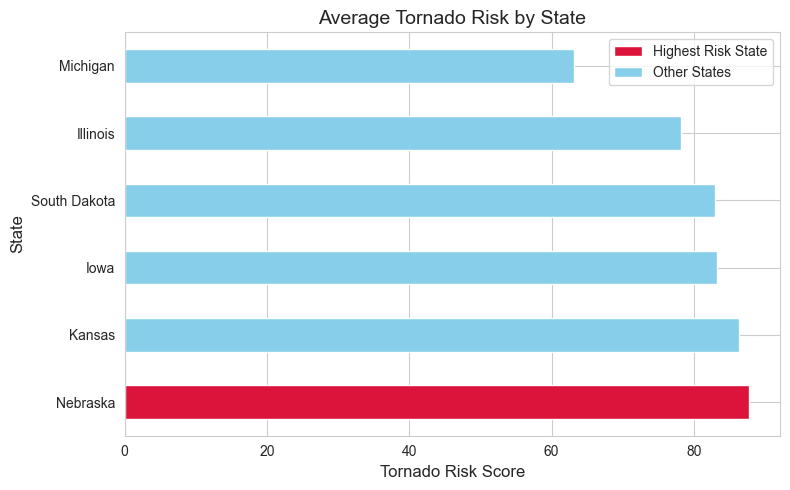

In [9]:
# Aggregate: mean tornado risk per state
state_summary = filtered_nri.groupby('STATE')[tornado_col].mean().sort_values()

# Plot
colors = ['skyblue' if x != state_summary.idxmax() else 'crimson' for x in state_summary.index]

plt.figure(figsize=(8,5))
state_summary.plot(kind='barh', color=colors)
plt.title('Average Tornado Risk by State', fontsize=14)
plt.xlabel('Tornado Risk Score', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.gca().invert_yaxis()  # Highest risk on top

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson', label='Highest Risk State'),
    Patch(facecolor='skyblue', label='Other States')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Part 3: Risk vs Population Analysis 

This part we will use the SVI Data to relate tornado risks in each state to population

---

# 3.1 Filter data (from SVI Data)

Filter data and group by state abbreviations  

---

In [12]:
#Tornado risk
state_summary = filtered_nri.groupby('STATE')[tornado_col].mean()

#Filter SVI Data
svi_filtered = svi_data[svi_data['STATE'].isin(states)][['STATE', 'E_TOTPOP']].copy()
svi_filtered['E_TOTPOP'] = pd.to_numeric(svi_filtered['E_TOTPOP'], errors = 'coerce')
svi_filtered = svi_filtered.dropna(subset = ['E_TOTPOP'])

svi_pop = svi_filtered.groupby('STATE')['E_TOTPOP'].sum()

#Merge SVI and NRI Data
risk_pop = pd.concat([state_summary, svi_pop], axis=1)
risk_pop.columns = ['Tornado Risk', 'Population']
risk_pop = risk_pop.dropna()

print(risk_pop)



              Tornado Risk  Population
STATE                                 
Illinois         78.206791    12757634
Iowa             83.251097     3188836
Kansas           86.324461     2935922
Michigan         63.215868    10057921
Nebraska         87.717304     1958939
South Dakota     83.005283      890342


# 3.2 Risk vs. Population Plot

This plot relates tornado risk and population in the different states

---

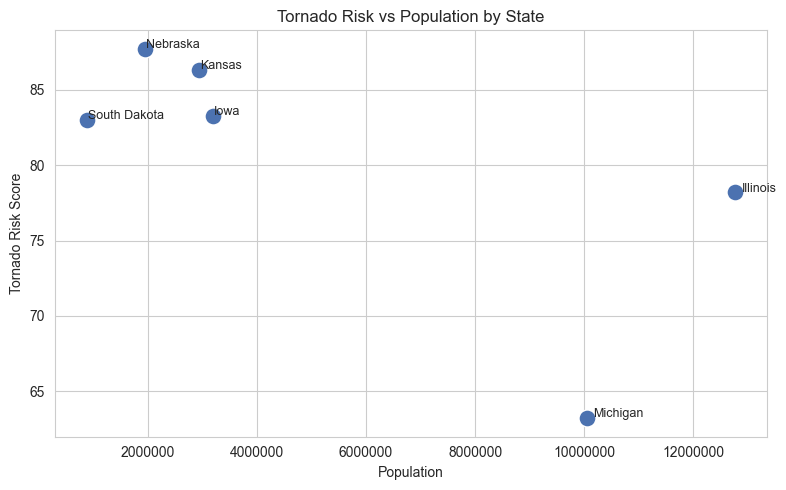

In [34]:
#scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=risk_pop,
    x='Population',
    y='Tornado Risk',
    s=150
)

plt.ticklabel_format(style='plain', axis='x')

# Labels
for state in risk_pop.index:
    plt.text(
        risk_pop.loc[state, 'Population'] * 1.01,
        risk_pop.loc[state, 'Tornado Risk'] + 0.05,
        state,
        fontsize=9
    )

plt.xlabel("Population")
plt.ylabel("Tornado Risk Score")
plt.title("Tornado Risk vs Population by State")

plt.tight_layout()
plt.show()

# Part 4: Geopandas

We will use Geopandas in order to create six maps for each state in order to compare risk in each county

---

# 4.1 Install and import

In [25]:
!pip install geopandas
import geopandas as gpd

## Read the Census Tracts data

tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

##Verifications for Shape files

tracts.head()

###This checks for Coordinate Reference System (CRS)

tracts.crs

###Checks the geometries in the data
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

# 4.2 Create risk maps for each state

Here we will create the maps to show risk in each county from each state

---

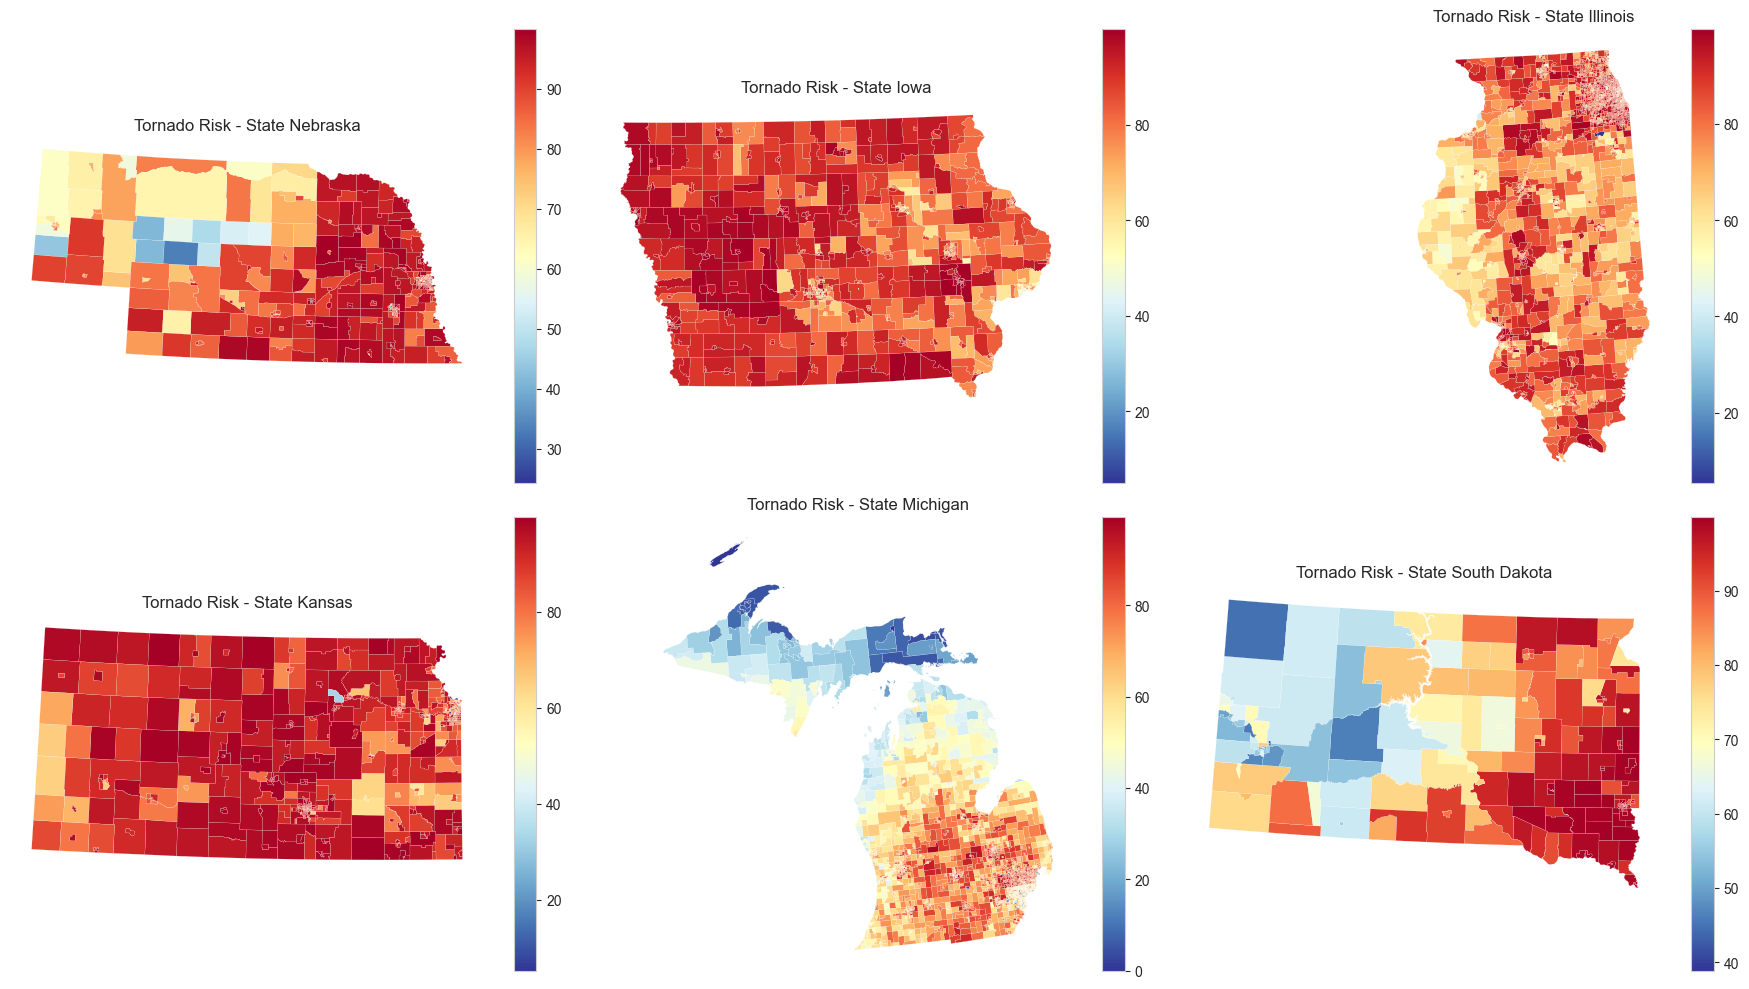

In [31]:
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")
if tracts.crs is None:
    tracts = tracts.set_crs("EPSG:4326")
tracts = tracts.replace(-9999, np.nan)

states = ["Nebraska", "Iowa", "Illinois", "Kansas", "Michigan", "South Dakota"]
geo = tracts[tracts["STATE"].isin(states)].copy()

if geo.empty:
    raise ValueError("No matching states found. Check STATE format in dataset.")

geo = geo.to_crs("ESRI:102003")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, st in enumerate(states):

    state_data = geo[geo["STATE"] == st]

    state_data.plot(
        column="TRND_RISKS",
        cmap="RdYlBu_r",
        legend=True,
        ax=axes[i],
        linewidth=0.1,
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(f"Tornado Risk - State {st}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()